In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import gzip
import scipy.sparse as sp
from collections import defaultdict
import sklearn
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from umap import UMAP
import seaborn as sns
import anndata as ad
from process import SpaHDSRL
import warnings
warnings.filterwarnings('ignore')
random_seed = 20

In [ ]:
adata_omics1 = sc.read_h5ad(r".\tutorial4\adata_omics1")
adata_omics2 = sc.read_h5ad(r".\tutorial4\adata_omics2")

In [ ]:
SpaHDSRL_result = SpaHDSRL(adata1=adata_omics1,adata2=adata_omics2)
SpaHDSRL_result.preprocessing_data(n_neighbors = 5)
SpaHDSRL_result.train(spatial_regularization_strength=0.008, z_dim=50, 
         lr=1e-3, wnn_epoch = 500, total_epoch=500, max_patience_bef=10, max_patience_aft=30, min_stop=200, 
         random_seed=random_seed, gpu=0, regularization_acceleration=True, edge_subset_sz=1000000, k_neighbors=5, gamma=0.05)
df_embedding = pd.DataFrame(SpaHDSRL_result.embedding)

Epoch 1/500, Loss: 1.391046166419983
Epoch 11/500, Loss: 1.175002932548523
Epoch 21/500, Loss: 0.9756157994270325
Epoch 31/500, Loss: 0.7376152873039246
Epoch 41/500, Loss: 0.5572872757911682
Epoch 51/500, Loss: 0.3789616823196411
Epoch 61/500, Loss: 0.2670365869998932
Epoch 71/500, Loss: 0.18473072350025177
Epoch 81/500, Loss: 0.13624973595142365
Epoch 91/500, Loss: 0.11063896119594574
Epoch 101/500, Loss: 0.08624590188264847
Epoch 111/500, Loss: 0.06748366355895996
Epoch 121/500, Loss: 0.05684439465403557
Epoch 131/500, Loss: 0.048237260431051254
Epoch 141/500, Loss: 0.042392924427986145
Epoch 151/500, Loss: 0.038001444190740585
Epoch 161/500, Loss: 0.03357397019863129
Epoch 171/500, Loss: 0.03001292236149311
Epoch 181/500, Loss: 0.026413507759571075
Epoch 191/500, Loss: 0.024312220513820648
Epoch 201/500, Loss: 0.024156058207154274
Epoch 211/500, Loss: 0.02175181917846203
Epoch 221/500, Loss: 0.019122358411550522
Epoch 231/500, Loss: 0.017518576234579086
Epoch 241/500, Loss: 0.02142

In [23]:
def screen_res(df_embedding, n_cluster = 5, res_s = 0.1, res_e = 1.0, step = 0.1):
    opt_res = res_s
    opt_clusters = n_cluster
    for res in np.arange(res_s,res_e,step):
        embedding_adata = sc.AnnData(df_embedding)
        sc.pp.neighbors(embedding_adata, n_neighbors=50, use_rep='X')
        sc.tl.leiden(embedding_adata, resolution=float(res))
        clusters = list(embedding_adata.obs["leiden"])
        cluster_num = len(np.unique(clusters))
        print('res = ' + str(round(res, 2)) + ', Cluster# = ' + str(cluster_num))
        if cluster_num == n_cluster:
            opt_res = res
            opt_clusters = clusters
    print('optimal res = ' + str(round(opt_res, 2)))
    return opt_res, opt_clusters

# Screening resoluti on that matches the given number of clusters 
opt_res_SpaHDSRL, opt_clusters_SpaHDSRL = screen_res(df_embedding,res_s = 0.5, res_e = 0.7, step = 0.01,n_cluster = 10)

res = 0.5, Cluster# = 10
res = 0.51, Cluster# = 10
res = 0.52, Cluster# = 10
res = 0.53, Cluster# = 9
res = 0.54, Cluster# = 9
res = 0.55, Cluster# = 9
res = 0.56, Cluster# = 10
res = 0.57, Cluster# = 10
res = 0.58, Cluster# = 10
res = 0.59, Cluster# = 10
res = 0.6, Cluster# = 10
res = 0.61, Cluster# = 9
res = 0.62, Cluster# = 9
res = 0.63, Cluster# = 10
res = 0.64, Cluster# = 10
res = 0.65, Cluster# = 10
res = 0.66, Cluster# = 10
res = 0.67, Cluster# = 10
res = 0.68, Cluster# = 10
res = 0.69, Cluster# = 10
optimal res = 0.69


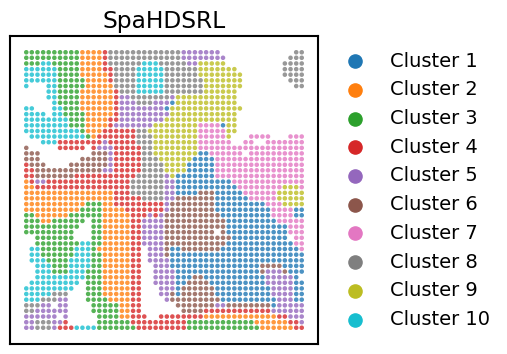

In [25]:
adata_new = adata_omics1.copy()
adata_new.obs["Cluster_SpaHDSRL"] = opt_clusters_SpaHDSRL
adata_plot = adata_new.copy()

cl = adata_plot.obs["Cluster_SpaHDSRL"].astype(str)
if set(cl.unique()).issubset(set([str(i) for i in range(1000)])):
    cl_int = cl.astype(int) + 1
    adata_plot.obs["Cluster_show"] = pd.Categorical(["Cluster %d" % i for i in cl_int])
else:
    adata_plot.obs["Cluster_show"] = pd.Categorical(["Cluster " + x for x in cl])

cats = sorted(adata_plot.obs["Cluster_show"].cat.categories,
              key=lambda x: int(x.split()[-1]) if x.split()[-1].isdigit() else x)
adata_plot.obs["Cluster_show"] = adata_plot.obs["Cluster_show"].cat.reorder_categories(cats, ordered=True)


plt.rcParams["font.family"] = "DejaVu Sans"  
plt.rcParams["font.size"] = 14

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
title = "SpaHDSRL"

sc.pl.spatial(
    adata_plot,
    color="Cluster_show",
    ax=ax,
    show=False,
    title=title,
    spot_size=28,
    alpha=0.8,           
    frameon=True,
    legend_loc="right margin"
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

leg = ax.get_legend()
if leg is not None:
    leg.set_title("")                  
    leg._loc = 6                       
    for h in leg.legend_handles:
        try:
            h.set_sizes([90])          
        except Exception:
            pass
plt.show()

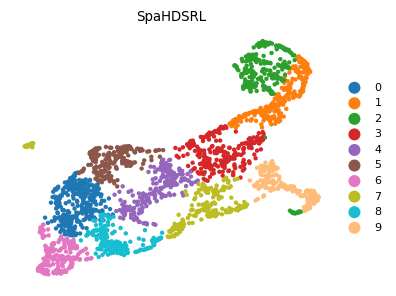

In [26]:
# UMAP visualization
umap_2d = UMAP(n_components=2, init='random', random_state=random_seed, min_dist = 0.3,n_neighbors=30)
umap_pos = umap_2d.fit_transform(df_embedding)
adata_new.obs['SpaHDSRL_umap_pos_x'] = umap_pos[:,0]
adata_new.obs['SpaHDSRL_umap_pos_y'] = umap_pos[:,1]

# Ploting figures
plot_color = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#bcbd22", "#17becf", "#ffbb78"
]
matplotlib.rcParams['font.size'] = 8.0
fig, axes = plt.subplots(1, 1, figsize=(4,3))
sz = 40
domains="Cluster_SpaHDSRL"
num_celltype=len(adata_new.obs[domains].unique())
adata_new.uns[domains+"_colors"]=list(plot_color[:num_celltype])
titles = 'SpaHDSRL'
ax=sc.pl.scatter(adata_new,alpha=1,x="SpaHDSRL_umap_pos_x",y="SpaHDSRL_umap_pos_y",color=domains,title=titles ,color_map=plot_color,show=False,size=sz,ax = axes)
ax.axis('off')
plt.tight_layout()